# Gaussian Mixture Models

Sometimes our data contains several overlapping populations.

For example, a galaxy colour distribution may contain a blue population and a red population. We observe all the galaxies together, but we do not know which population generated each individual point.

A Gaussian mixture model assumes that the full distribution is a weighted sum of $K$ Gaussian distributions:

$$
p(x_i|\boldsymbol{\theta})
=
\sum_{k=1}^{K}
\pi_k
\mathcal{N}(x_i|\mu_k,\sigma_k)
$$

where:

1. $\mu_k$ is the mean of component $k$
2. $\sigma_k$ is its standard deviation
3. $\pi_k$ is the fraction of the population belonging to component $k$

The weights must satisfy:

$$
\sum_{k=1}^{K}\pi_k=1
$$


The difficult part is that we do not know which Gaussian generated each point.

## Hidden Labels, Bayes' Rule and $\gamma_{ik}$

Let $z_i$ be the hidden class label of point $x_i$.

If $z_i=k$, then point $x_i$ was generated by Gaussian component $k$.

We do not observe $z_i$, so we use Bayes' rule to calculate the probability that component $k$ generated point $x_i$:

$$
\gamma_{ik}
=
p(z_i=k|x_i,\boldsymbol{\theta})
$$

$$
\gamma_{ik}
=
\frac{
p(x_i|z_i=k,\boldsymbol{\theta})
p(z_i=k|\boldsymbol{\theta})
}{
\sum_{j=1}^{K}
p(x_i|z_i=j,\boldsymbol{\theta})
p(z_i=j|\boldsymbol{\theta})
}
$$

For a Gaussian mixture:

$$
\gamma_{ik}
=
\frac{
\pi_k
\mathcal{N}(x_i|\mu_k,\sigma_k)
}{
\sum_{j=1}^{K}
\pi_j
\mathcal{N}(x_i|\mu_j,\sigma_j)
}
$$

$\gamma_{ik}$ is called the responsibility.

It tells us how much component $k$ is responsible for point $i$.

For example:

$$
\gamma_{i1}=0.8,
\qquad
\gamma_{i2}=0.2
$$

means that the model gives point $i$ an $80\%$ probability of coming from component 1 and a $20\%$ probability of coming from component 2.

For every point:

$$
\sum_{k=1}^{K}\gamma_{ik}=1
$$

(In the AstroML documentation this is called the following, but was omitted as I enjoyed the youtube videos)

$$
w_{ij}=p(j|x_i)
$$

Therefore, $\gamma_{ik}$ in the videos is the same as $w_{ij}$ in astroML.

## Expectation Maximisation

If the hidden labels were known, we could separate the points into groups and fit one Gaussian to each group.

Expectation maximisation replaces the unknown labels with their expected values, $\gamma_{ik}$.

Start by initialising:

$$
\mu_k,\qquad \sigma_k,\qquad \pi_k
$$

Then repeat the following two steps.

### E-step

Use the current parameter estimates, $\boldsymbol{\theta}^{\mathrm{old}}$, to calculate every responsibility:

$$
\gamma_{ik}=p(z_i=k|x_i,\boldsymbol{\theta}^{\mathrm{old}})
$$

These responsibilities are then used to form the expected complete-data log-likelihood:

$$
Q(\boldsymbol{\theta}|\boldsymbol{\theta}^{\mathrm{old}})=\mathbb{E}_{z|x,\boldsymbol{\theta}^{\mathrm{old}}}\left[\ln p(x,z|\boldsymbol{\theta})\right]
$$

This basically means "Calculate the average complete data log-likelihood, using our current probabilities for the unknown class labels."

For a Gaussian mixture:

$$
Q(\boldsymbol{\theta}|\boldsymbol{\theta}^{\mathrm{old}})=\sum_{i=1}^{N}\sum_{k=1}^{K}\gamma_{ik}\left[\ln \pi_k+\ln \mathcal{N}(x_i|\mu_k,\sigma_k)\right]
$$

This means, "For every point and every Gaussian, calculate its log-likelihood contribution and weigh it by the probability that the point belongs to that Gaussian."

The expectation is calculated using the old/current parameters, while $Q$ is treated as a function of the possible new parameters.

### M-step

Choose the new parameters which maximise the expected log-likelihood:

$$
\boldsymbol{\theta}^{\mathrm{new}}=\underset{\boldsymbol{\theta}}{\operatorname{argmax}}\;Q(\boldsymbol{\theta}|\boldsymbol{\theta}^{\mathrm{old}})
$$

For a one-dimensional Gaussian mixture, this gives:

$$
N_k=\sum_{i=1}^{N}\gamma_{ik}
$$

$$
\mu_k^{\mathrm{new}}=\frac{\sum_i\gamma_{ik}x_i}{N_k}
$$

$$
(\sigma_k^2)^{\mathrm{new}}=\frac{\sum_i\gamma_{ik}(x_i-\mu_k^{\mathrm{new}})^2}{N_k}
$$

$$
\pi_k^{\mathrm{new}}=\frac{N_k}{N}
$$

So the whole process is simply:

$$
\text{Initialise }\mu_k,\sigma_k,\pi_k
$$

$$
\downarrow
$$

$$
\text{E-step: calculate }\gamma_{ik}\text{ and }Q
$$

$$
\downarrow
$$

$$
\text{M-step: update }\mu_k,\sigma_k,\pi_k\text{ to maximise }Q
$$

$$
\downarrow
$$

$$
\text{Repeat until the parameters stop changing}
$$



In [22]:
import numpy as np
from sklearn.mixture import GaussianMixture
random_state = np.random.RandomState(seed=1)

X = np.concatenate([random_state.normal(-1, 1.5, 350),
                    random_state.normal(0, 1, 500),
                    random_state.normal(3, 0.5, 150)]).reshape(-1, 1)

N = np.arange(1, 11)
models = [None for i in range(len(N))]

for i in range(len(N)):
    models[i] = GaussianMixture(N[i]).fit(X)

AIC = [m.aic(X) for m in models]
BIC = [m.bic(X) for m in models]

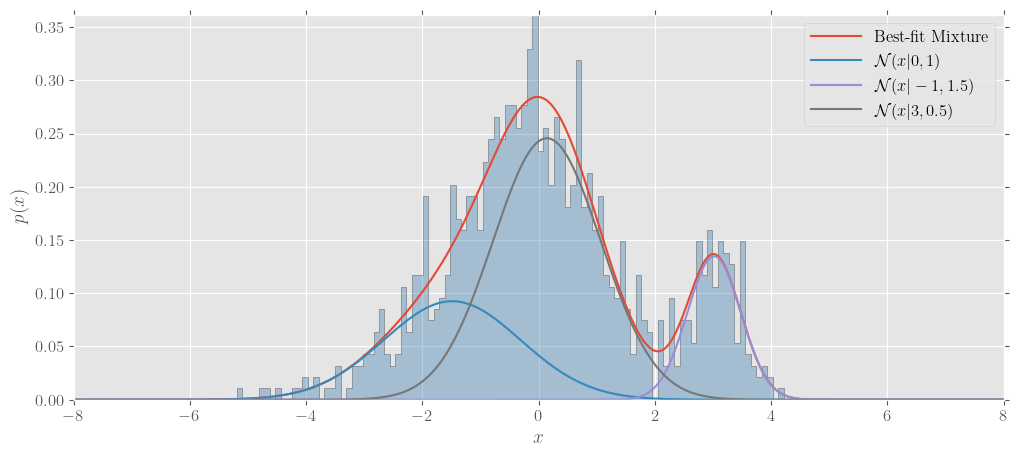

In [23]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')


fig = plt.figure(figsize=(12, 5))
x = np.linspace(-8, 8, 1000)

M_best = models[np.argmin(AIC)] 
logprob = M_best.score_samples(x.reshape(-1, 1))
responsibilities = M_best.predict_proba(x.reshape(-1, 1))
pdf = np.exp(logprob)
pdf_individual = responsibilities * pdf[:, np.newaxis]

labels = ['Best-fit Mixture','$\mathcal{N}(x|0,1)$',
          '$\mathcal{N}(x|-1,1.5)$','$\mathcal{N}(x|3,0.5)$']

plt.hist(X, 100, density=True, histtype='stepfilled', 
        alpha=0.4,color = 'steelblue',edgecolor = 'black')

#Plot the Gaussian mixture
plt.plot(x, pdf, label = labels[0])

#Plot the individual Gaussians
for i, j in enumerate([1,2,3]):
    plt.plot(x,pdf_individual[:,i],label = labels[j])
    

plt.xlabel('$x$', fontsize = 14)
plt.ylabel('$p(x)$', fontsize = 14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.legend(fontsize = 12);

## Accounting for Measurement Errors

So far, we have assumed that the measurement errors are negligible compared with the widths of the Gaussian components.

If every point has the same Gaussian uncertainty, $e$, then the observed width contains both the intrinsic spread and the measurement error.

The intrinsic width can be estimated using:

$$
\sigma_k^*=\sqrt{\sigma_k^2-e^2}
$$

where $\sigma_k^*$ is the intrinsic width and $\sigma_k$ is the observed width.

If every point has a different uncertainty, $e_i$, then the measurement error must be included directly in the Gaussian width:

$$
\sqrt{\sigma_k^2+e_i^2}
$$

so that:

$$
p(x_i|k)=\mathcal{N}\left(x_i\middle|\mu_k,\sqrt{\sigma_k^2+e_i^2}\right)
$$

In this case, the standard EM variance update no longer works directly because every point has a different effective width, so the parameters must be found numerically.

First we will do the task that is at the end of Lecture06 within bicocca_2026.

In [24]:
from matplotlib import pyplot as plt
import numpy as np
from sklearn.mixture import GaussianMixture
from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=13, usetex=True)
# Set a seed for reproducibility
random_state = np.random.RandomState(seed=512)
import os

Y = np.concatenate([random_state.normal(9, 5, 350),
                    random_state.normal(40, 3, 600),
                    random_state.normal(3, 5, 200)]).reshape(-1, 1)

if not os.path.isfile("formationchannels.npy"):
    np.save("formationchannels.npy",Y)

(array([ 1.,  0.,  2.,  2.,  2.,  1.,  3.,  1.,  6.,  5.,  6., 18.,  4.,
        10.,  7., 14., 14., 14., 17., 12., 15., 13., 20., 20., 26., 17.,
        24., 29., 16., 15., 22., 19., 16., 23., 13., 16., 18., 14.,  8.,
        15., 10.,  5., 15.,  4.,  1.,  0.,  4.,  1.,  2.,  3.,  0.,  1.,
         4.,  0.,  1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  2., 11., 13., 13., 22.,
        20., 34., 30., 40., 39., 49., 46., 45., 42., 40., 34., 28., 27.,
        25., 13.,  8.,  5.,  5.,  4.,  2.,  1.,  1.]),
 array([-9.12970235, -8.54829959, -7.96689684, -7.38549408, -6.80409133,
        -6.22268857, -5.64128582, -5.05988306, -4.47848031, -3.89707755,
        -3.3156748 , -2.73427204, -2.15286929, -1.57146653, -0.99006378,
        -0.40866102,  0.17274173,  0.75414449,  1.33554724,  1.91695   ,
         2.49835275,  3.07975551,  3.66115826,  4.24256102,  4.82396377,
         5.40536653,  5.98676928,  6.56817204,  7.14957479,  7.730977

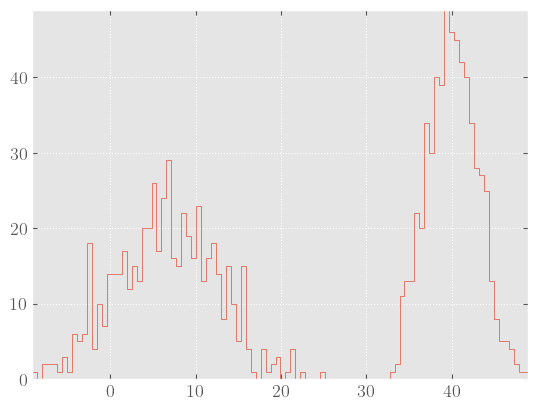

In [25]:
#examine the data
Y=np.load("formationchannels.npy")

plt.hist(Y, bins = 100, histtype= "step")

Text(0, 0.5, 'Information criterion')

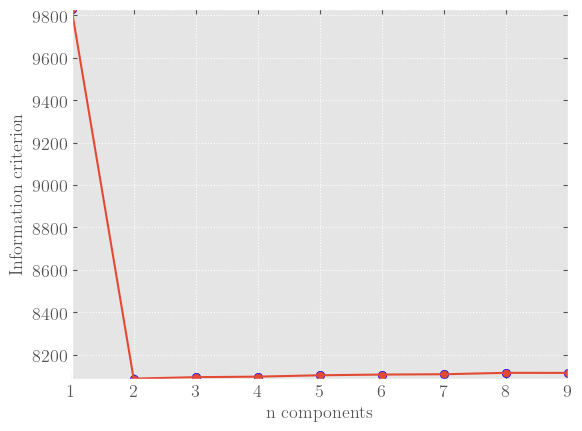

In [26]:
Ns = np.arange(1,10)

models = [GaussianMixture(N).fit(Y) for N in Ns] 

AIC = [m.aic(Y) for m in models]

plt.plot(Ns, AIC)
plt.scatter(Ns, AIC)

plt.xlabel("n components")
plt.ylabel("Information criterion")

We can clearly see that the AIC is minimised for N = (lowest value, I keep changing it so I will leave it as this)

Or we can just find it as well such as:

In [27]:
print('The AIC is minimized for N=', Ns[np.argmin(AIC)])

The AIC is minimized for N= 2


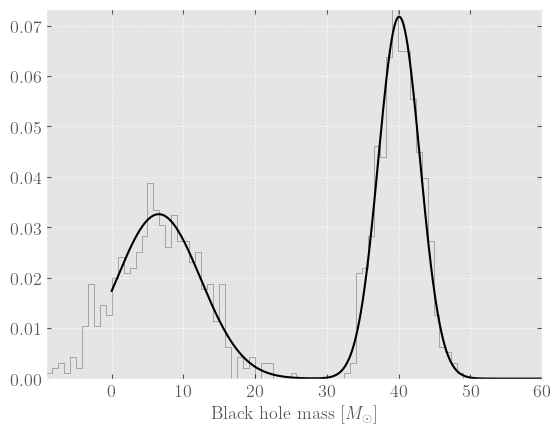

In [28]:
M_best = models[np.argmin(AIC)]

x = np.linspace(0, 60, 1000)
logprob = M_best.score_samples(x.reshape(-1, 1))
pdf = np.exp(logprob)

plt.hist(Y, 70, density=True, histtype='step', alpha=0.4,color='black')

plt.plot(x, pdf, 'k')

plt.xlabel("Black hole mass $[M_\odot]$");

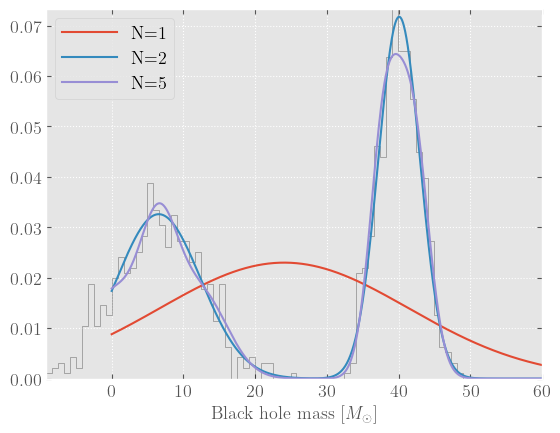

In [29]:
plt.hist(Y, 70, density=True, histtype='step', alpha=0.4,color='black')

for index in np.argmin(AIC)+np.array([-1,0,3]):

    logprob = models[index].score_samples(x.reshape(-1, 1))
    plt.plot(x, np.exp(logprob),label='N='+str(Ns[index]))

plt.xlabel("Black hole mass $[M_\odot]$")
plt.legend();

Here we compared results for when we have N = 3, N = 4 and N = 7 parameters. Even though N=7 looks better, we use Occams razor to say that capturing those additional details isn't enough to justify adding more parameters

## Lecture 7 - Hypothesis testing, Comparing distributions, Nonparametric models, KDE

Sometimes in statistics, we wish to ask whether a given sample is consistent with some hypothesis. For example we may be interested in whether a measured value, or a whole set, ${x_i}$, is consistent with being drawn from a set distribution.

Say its a Gaussian distribution. Here $N(\mu, \sigma)$ is our null hypothesis and it corresponds to a "no effect" case.

We are trying to reject it to demonstrate that we measured some effect. We reject the null hypothesis when the p value is less than or equal to the significance level, $\alpha$.

probability that your data could have occurred, assuming the null hypothesis is correct. It does this by calculating the likelihood of your test statistic, the number calculated by a statistical test using your data. The smaller the p-value, the more likely the alternative hypothesis is correct.

For this, it is assumed that we can compute a probability of the given outcome from the null hypothesis.

When performing tests we are likely to make two errors
1. Type I: The null hypothesis is true but incorrectly rejected
2. Type II: The null hypothesis is false but is not rejected

When increasing $\alpha$, the number of false positives decreases as we would reject the null hypothesis less. But the number of false negatives increases.

Also, when increasing the number of hypothesis tests we do simultaneously, the proportion of false positives can become much higher than the chosen significance

Fraction of false positives depends on:
1. Significance level
2. Total number of data points
3. The number of true positives (how often the alternate hypothesis is true)

The underlying distribution from where the data, ${x_i}$ were drawn, $h(x)$ is the sum of two populations:

$$\qquad\qquad\qquad h(x) = (1-a)\: h_B(x)+ah_S(x), \qquad\qquad\qquad $$

Where $h(x)$ represents the total pdf of the mixture, $h_B(x)$ is the probability density of the background population (B), $h_S(x)$ is the probability density of the source population (S). a is the fraction of the total sample that belongs to S, and vice versa for (1-a)

### We can look at a simple version of the problem in classification:

Here we assign the class S or B without retaining the knowledge of the actual probability, $p_s$.

If we choose a classification boundary value, $x_c$ , (so if greater than $x_c$ it is classified into one class and vice versa) then the expected number of false positive sources (Type I errors) in the sample $Na$ is

$$n_\text{ false positive} = N (1-a) \int^\infty_{x_c}h_B(x) dx \equiv N(1-a) \alpha ,$$

Here, the integral computes the probability that background noise randomly produces a measurement higher than $x_c$, and $N(1-a)$ is the total number of background noise data points

And the number of Type II errors (false negatives) is

$$n_\text{ false negative} = Na\int^{x_c}_0 h_s(x)dx \equiv Na\beta.$$

Now looking at probability that a real source produces a signal that is fainter than $x_c$

The number of instances that the null hypothesis is rejected (classified as a source):

$$n_\text{ source} = Na-n_\text{ false negative}+n_\text{ false positive}$$

We can define the sample completeness, which is the fraction of all true sources in the dataset 

$$\eta = \frac{Na-n_\text{ false negative}}{Na} = 1 -\int^{x_c}_0 h_S(x)dx$$

And can define the sample contamination or false discovery rate (FDR): 

$$\epsilon = \frac{n_\text{ false positive}}{n_\text{ source}}$$


So essentially, as $x_c$ increases, the sample contamination decreases, as background noise has less of a chance of producing this signal. However, our completeness decreases which is bad. To evaluate the ideal spot we can use a reciever operating characteristic (ROC) curve. Where we plot the fraction of true positives vs the fraction of true negatives

Assume that $h_B(x) = \mathcal{N}(\mu = 100, \sigma = 10)$ and $h_S(x) = \mathcal{N}(\mu = 150, \sigma = 12)$, with **$a = 0.1$** and $N = 10^6$ (this will be an image with $1000 \times 1000$ resolution elements; the $x$ values correspond to the sum of background and source counts). We will plot these two distributions below.

If we naively choose $x_c = 120$ (a "$2\sigma$ cut" away from the mean for $h_B$, corresponding to a Type I error probability of $\alpha = 0.024$), **21,600 values will be incorrectly classified as a source!** The sample completeness for this value of $x_c$ is $0.994$ and **99,400 values are correctly classified as a source.** Although the Type I error rate is only $0.024$, the sample contamination is:

$$\frac{21,600}{21,600 + 99,400} = 0.179$$

or over 7 times higher!

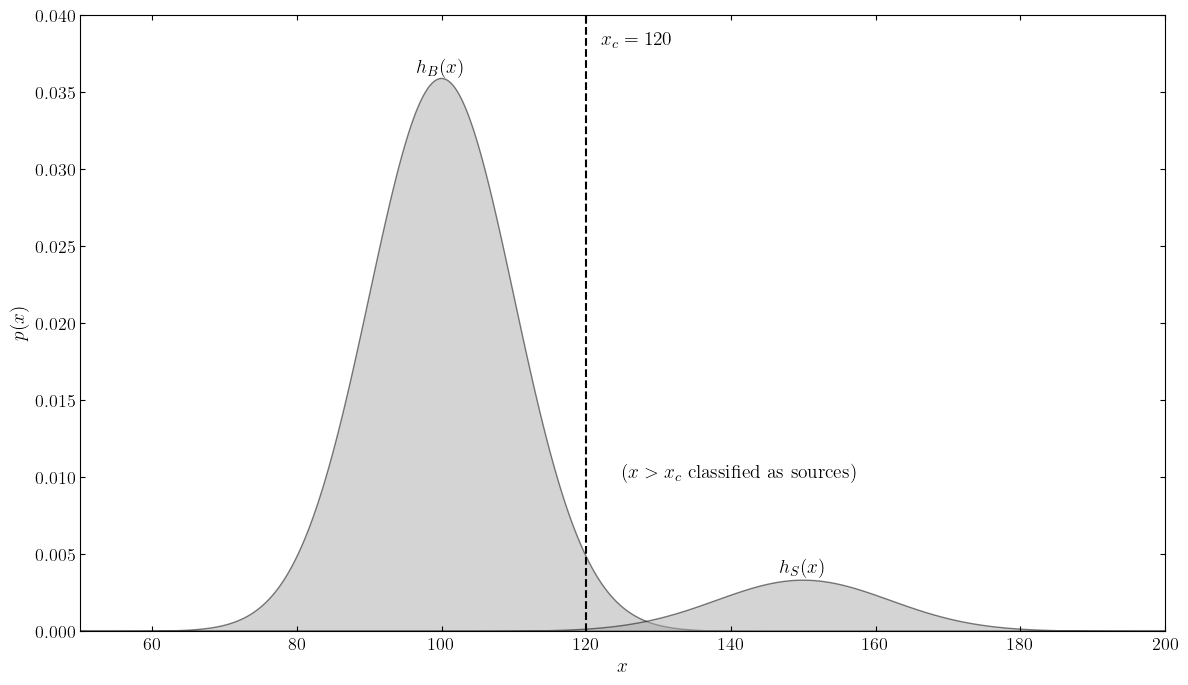

In [65]:
import numpy as np
from scipy.stats import norm
from matplotlib import pyplot as plt

# Generate and draw the curves
x = np.linspace(50, 200, 1000)
p1 = 0.9 * norm(100, 10).pdf(x)
p2 = 0.1 * norm(150, 12).pdf(x) # Only 10% of the data has a real source

# plot the distributions
fig, ax = plt.subplots(figsize=(14, 8))
ax.fill(x, p1, ec='k', fc='#AAAAAA', alpha=0.5)
ax.fill(x, p2, '-k', fc='#AAAAAA', alpha=0.5)

# plot x_c = 120
ax.plot([120, 120], [0.0, 0.04], '--k')

ax.text(100, 0.036, r'$h_B(x)$', ha='center', va='bottom', fontsize = 14)
ax.text(150, 0.0035, r'$h_S(x)$', ha='center', va='bottom', fontsize = 14)
ax.text(122, 0.039, r'$x_c=120$', ha='left', va='top', fontsize = 14)
ax.text(125, 0.01, r'$(x > x_c\ {\rm classified\ as\ sources})$', fontsize = 14)

ax.set_xlim(50, 200)
ax.set_ylim(0, 0.04)

ax.set_xlabel('$x$', fontsize = 14)
ax.set_ylabel('$p(x)$', fontsize = 14)
plt.show()

The result that the contamination is much greater than the Type I error rate ($\alpha$) is due to the imbalance of the sample sizes.

Since the number of background points outnumbers the real sources, a very small percentage of false alarms create a large amount of false positives.

To decrease $\epsilon$, we need to increase $x_c$. But the optimal value depends on $a$ which is usually unknown.

##### Benjamini and Hochberg method

And the method dynamically finds a threshold that guarantees your contamination stays below a target limit $\epsilon_0$:

Assumes that measurements can be described by:

$$\qquad\qquad\qquad h(x) = (1-a)\: h_B(x)+ah_S(x), \qquad\qquad\qquad $$

And we make the assumption that we know $h_B(x)$ and its cumulative distribution.

For every measurement, we compute its tail probability (p-value) under the null (background) hypothesis:

$$p_i = 1 - H_B(x_i)$$

Here, a very bright signal (large $x_i$) will cause a very small p-value

Then we sort the sample in ascending order.

Now, if there were no real signals and we just have pure background (all drawn from $h_B(x)$), the sorted p values would be uniformly distributed between 0 and 1. The cumulative count of p-values less than or equal to $p_i$ would follow a straight diagonal line.

$$C_i^B = Np_i$$

However, for $Na$ cases in the model, the null hypothesis is false and will result in an excess of $p_i$ values. So real sources produce an excess of extremely small p values.

Due to this, the cumulative count curve, $C_i = i$, climbs much faster and sits far above the pure noise diagonal near. This fact alone can be used to find a classification threshold, $p_c$.

Assume that the null hypothesis is rejected for all values $p_i \leq p_c$, resulting in a subsample of $i_c = C(p_c)$ where these $i_c$ values are selected as sources. 

Out of N total measurements, the expected number of pure noise points incorrectly flagged below threshold $p_c$ (false positives) is

$$(1 - a)Np_c < Np_c$$

The total number of candidates flagged is $i_c$

Hence, the contamination rate is:

$$\epsilon = \frac{(1-a)Np_c}{i_c} < \frac{Np_c}{i_c}$$

And so the threshold value must satisfy

$$\qquad\qquad\qquad\qquad i_c < N\frac{p_c}{\epsilon_0} \qquad\qquad\qquad\qquad $$

This condition corresponds to the intersection of the measured $C_i(p_i)$ curve and the straight line $C = Np/\epsilon_0$


Now lets look at the method in action with code:


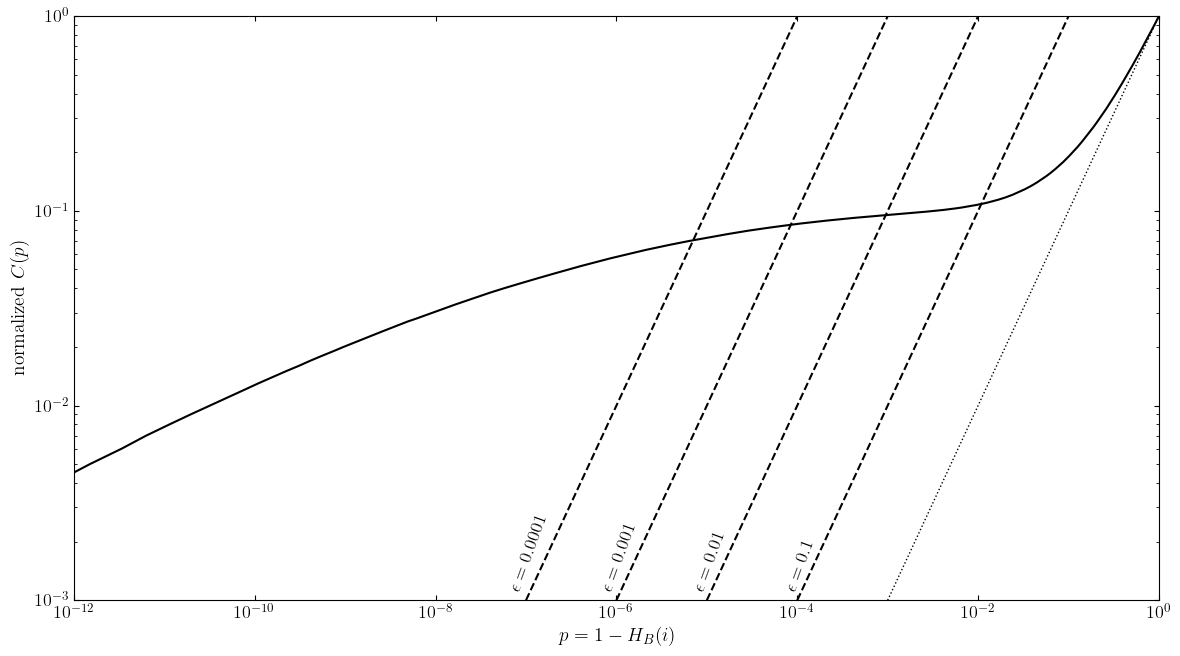

In [66]:
import numpy as np
from scipy.stats import norm
from matplotlib import pyplot as plt

#------------------------------------------------------------
# Set up the background and foreground distributions
background = norm(100, 10)
foreground = norm(150, 12)
f = 0.1

# Draw from the distribution
np.random.seed(42)
N = int(1E6)
X = np.random.random(N)
mask = (X < 0.1)
X[mask] = foreground.rvs(np.sum(mask))
X[~mask] = background.rvs(np.sum(~mask)) # counts all the background measurements (should be around 9 times larger than the foreground ones)


#------------------------------------------------------------
# Perform Benjamini-Hochberg method
p = 1 - background.cdf(X)
p_sorted = np.sort(p) # Here we just sort it like we explained above


# plot the results
fig = plt.figure(figsize=(14, 8))
fig.subplots_adjust(bottom=0.15)
ax = plt.axes(xscale='log', yscale='log')

# only plot every 1000th; plotting all 1E6 takes too long
ax.plot(p_sorted[::1000], np.linspace(0, 1, 1000), '-k')
ax.plot(p_sorted[::1000], p_sorted[::1000], ':k', lw=1)

# plot the cutoffs for various values of expsilon
p_reg_over_eps = 10 ** np.linspace(-3, 0, 100)
for (i, epsilon) in enumerate([0.1, 0.01, 0.001, 0.0001]):
    x = p_reg_over_eps * epsilon
    y = p_reg_over_eps
    ax.plot(x, y, '--k')

    ax.text(x[1], y[1],
            r'$\epsilon = %.1g$' % epsilon,
            ha='center', va='bottom', rotation=70)

ax.xaxis.set_major_locator(plt.LogLocator(base=100))

ax.set_xlim(1E-12, 1)
ax.set_ylim(1E-3, 1)

ax.set_xlabel('$p = 1 - H_B(i)$', fontsize = 14)
ax.set_ylabel('normalized $C(p)$', fontsize = 14)

plt.show()

Points on the far left are very bright sources and on the right its pure background. On the y-axis, $10^{-3}$ means that 0.1% of the 10^6 points fall to the left of that p-value.

The solid line shows the CDF of observed p values, normalized by the sample size. The dashed lines show the cutoff for various limits on the contamination rate computed using $i_c < N\frac{p_c}{\epsilon_0}$. The accepted measurements are those with a p smaller than the intersection of solid and dashed curves.

So the way to use this plot is look at the intersection of the dashed and solid line, trace back down to a p-value. This is the $p_c$. From this intersection look to the left to y-axis and multiply by 10^6, this is your number of items flagged as sources.

Any measurement with a p-value smaller than $p_c$ (lying to the left of the intersection) is a detected source. 

You just choose how many of the detections you want as false alarms to pick the dashed line you want.

## Comparing Distributions

Hypothesis testing strongly links with this. We can compare the shape, location and width of distributions.

If you can safely assume the shape is Gaussian, then you can compare the location and scale (variance). If you can't assume the shape you have to use nonparametric tests.

> Just to note! Two identical distributions can look different if you filter them differently, e.g the lowest quartile vs the full dataset.

But the whole point of statistical tests is:
1. Assume a null hypothesis, a baseline assumption that there is no real difference between distributions
2. Calculate a test statistic, compute a value based on the sample data
3. Assuming the null hypothesis is true, you calculate the probability of getting a result at least that extreme
4. Make a decision between the p-value and your significance level

#### Nonparametric methods for comparing distributions

Nonparametric here means that the distributions are not known. The most popular is the Kolmogorov-Smirnov test. 

This compares the cumulative distribution function, $F(x)$, for two samples.

It measures the maximum distance of the two cumulative distributions:

$$D = \text{max}|F_1(x1) - F_2(x2)|$$

where $0 \leq D \leq 1$

Let's visualise this

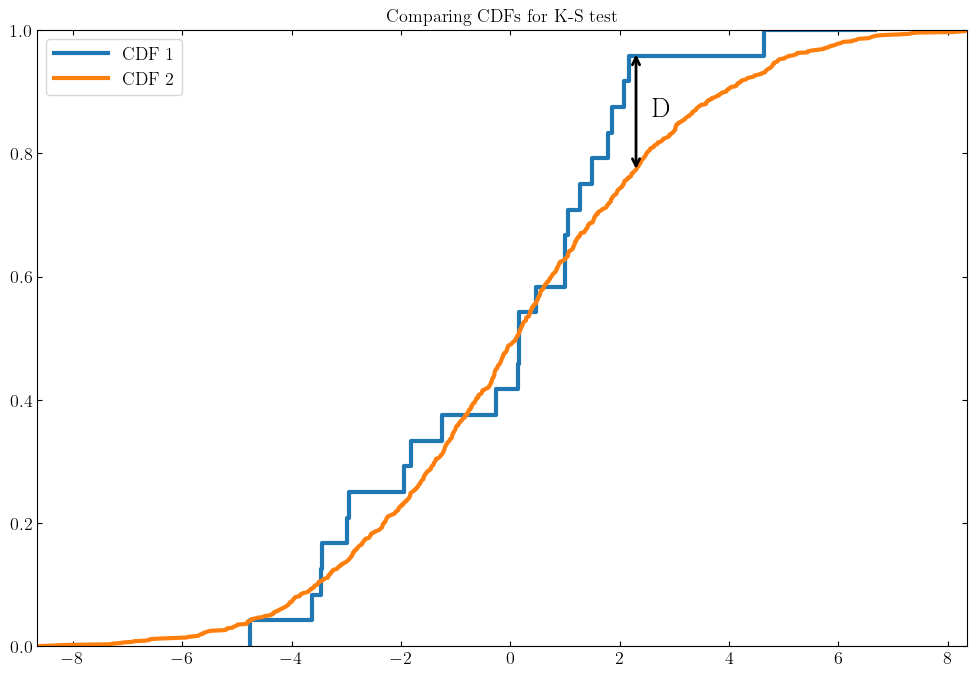

In [67]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(4)
plt.figure(figsize=(12, 8))

plt.step(np.sort(stats.norm.rvs(0,3,25)), np.linspace(0, 1, 25) ,lw = 3)
plt.plot(np.sort(stats.norm.rvs(0,3,1000)), np.linspace(0, 1, 1000), lw=3)

plt.annotate("", xy=(2.3, 0.965), xytext=(2.3, 0.77),
            arrowprops=dict(arrowstyle="<->",lw=2))

plt.text(2.6,0.86, "D", fontsize = 20)

plt.legend(['CDF 1', 'CDF 2'])
plt.title('Comparing CDFs for K-S test')
plt.show()

So then we ask ourselves if the value of D is significant. ie, How likely is it to get a distance of size D purely by random chance, if both samples came from the same distribution?

The probability of obtaining by chance a value of D larger than the measured value is given by the function

$$\qquad \qquad \qquad Q_{KS}(\lambda) = 2\sum^{\infty}_{k=1} (-1)^{k-1}e^{-2k^2\lambda^2} \qquad\qquad\qquad (1) $$

where

$$\lambda = \bigg(0.12 + \sqrt{n_e} + \frac{0.11}{\sqrt{n_e}}\bigg)D$$

where the number of effective data points is

$$n_e = \frac{N_1N_2}{N_1 +N_2}.$$

For $n_e$ greater than about 10 or so, we can bypass Eq 1 and use the following approximation to evaluate D corresponding to a given probability $\alpha$ of obtaining a value at least that large:

$$D_{KS} = \frac{C(\alpha)}{\sqrt{n_e}}$$

And the ability to reject the null hypothesis (if its false) increases with the denominator

Let's look at the python implementation:

In [68]:
np.random.seed(42)

# the kstest function is appropriate for this
x = np.random.normal(loc=0, scale=1, size=100000)
print(stats.kstest(x, 'norm'))

KstestResult(statistic=np.float64(0.0016222702520980459), pvalue=np.float64(0.9546236463863305), statistic_location=np.float64(0.7711205862750051), statistic_sign=np.int8(-1))


Now compare a student t distribution with 100 degrees of freedom to a gaussian:

In [69]:
print(stats.kstest(stats.t.rvs(df=100, size=10000000), 'norm'))

KstestResult(statistic=np.float64(0.0016819058855743335), pvalue=np.float64(5.368266640572133e-25), statistic_location=np.float64(-1.5339352285013885), statistic_sign=np.int8(1))


In [70]:
print(stats.ks_2samp(stats.t.rvs(df=100, size=100), np.random.normal(loc=0, scale=1, size=100) ))

KstestResult(statistic=np.float64(0.14), pvalue=np.float64(0.2819416298082479), statistic_location=np.float64(-0.36953718057991936), statistic_sign=np.int8(-1))


### References

- Ivezić et al., *Statistics, Data Mining, and Machine Learning in Astronomy*, Section 4
- [MLE Applied to Gaussian Mixtures (astroML)](https://www.astroml.org/astroML-notebooks/chapter4/astroml_chapter4_Gaussian_mixtures.html)
- [Gaussian Mixture Models video 1](https://www.youtube.com/watch?v=wT2yLNUfyoM)
- [Gaussian Mixture Model video 2](https://www.youtube.com/watch?v=EWd1xRkyEog)
- [Comparing distributions (astroML)](https://www.astroml.org/astroML-notebooks/chapter4/astroml_chapter4_Comparison_of_distributions.html#)
- [Hypothesis testing](https://www.astroml.org/astroML-notebooks/chapter4/astroml_chapter4_Hypothesis_testing.html)